In [1]:
# Basic Python packages
!pip install --upgrade pip
!pip install unstructured[pdf] pdfplumber camelot-py[cv] pdf2image pytesseract pillow pandas tqdm matplotlib opencv-python-headless seaborn lxml beautifulsoup4

# System packages (Ubuntu/Debian) – run on the machine/VM, not in pip
# sudo apt-get update
# sudo apt-get install -y poppler-utils ghostscript tesseract-ocr

# Optional (better OCR): install tesseract language packs if needed:
# sudo apt-get install -y tesseract-ocr-eng

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 33.1 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 10.6 MB/s  0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
INFO: pip is looking at multiple versions of unstructured-client to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 18.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 39.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.1/18.1 MB 85.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 123.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 86.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
import os
from google.colab import userdata

# Retrieve API keys from Colab secrets
# Ensure your OPENAI_API_KEY and GROQ_API_KEY are stored in Colab's Secrets Manager
deepseek_api_key = userdata.get("DEEPSEEK_API_KEY")
groq_api_key = userdata.get("GROQ_API_KEY")

if not deepseek_api_key:
    raise ValueError("DEEPSEEK_API_KEY not found in Colab secrets. Please add it to the secrets manager.")
if not groq_api_key:
    raise ValueError("GROQ_API_KEY not found in Colab secrets. Please add it to the secrets manager.")

os.environ["DEEPSEEK_API_KEY"] = deepseek_api_key
os.environ["GROQ_API_KEY"] = groq_api_key
os.environ["LANGCHAIN_API_KEY"] = deepseek_api_key # Assuming Langchain uses OpenAI key for now, adjust if needed
os.environ["LANGCHAIN_TRACING_V2"] = "true"


### **Extract the data**
#### **Extract the elements of the PDF that we will be able to use in the retrieval process. These elements can be: Text, Images, Tables, Charts etc.**

In [4]:
file_path = "/content/drive/MyDrive/New_Ecommerce/Ecommerce_Sales_Prediction.ipynb2.pdf"

In [5]:
# System packages (Ubuntu/Debian) – run on the machine/VM, not in pip
!sudo apt-get update
!sudo apt-get install -y poppler-utils ghostscript tesseract-ocr

# Optional (better OCR): install tesseract language packs if needed:
!sudo apt-get install -y tesseract-ocr-eng

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,860 kB]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:9 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,287 kB]
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,573 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,633 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:14 http://s

In [6]:
!pip uninstall fitz

In [7]:
!pip install PyMuPDF

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.1/24.1 MB 42.9 MB/s  0:00:00


In [8]:
import fitz  # PyMuPDF
import pandas as pd
from PIL import Image
import io
import os

class PDFExtractor:
    def __init__(self, file_path):
        self.file_path = file_path
        self.doc = fitz.open(file_path)
        self.output_dir = "extracted_content"

        # Create output directories
        os.makedirs(f"{self.output_dir}/images", exist_ok=True)
        os.makedirs(f"{self.output_dir}/tables", exist_ok=True)
        os.makedirs(f"{self.output_dir}/text", exist_ok=True)

    def extract_embedded_images(self):
        """Extract all embedded images from the PDF"""
        print("Extracting embedded images...")
        image_count = 0

        for page_num in range(len(self.doc)):
            page = self.doc[page_num]
            image_list = page.get_images(full=True)

            for img_index, img in enumerate(image_list):
                xref = img[0]
                base_image = self.doc.extract_image(xref)
                image_bytes = base_image["image"]
                image_ext = base_image["ext"]

                # Save image
                image_filename = f"{self.output_dir}/images/page_{page_num + 1}_embedded_img_{img_index + 1}.{image_ext}"
                with open(image_filename, "wb") as img_file:
                    img_file.write(image_bytes)

                image_count += 1
                print(f"Saved embedded image: {image_filename}")

        print(f"Total embedded images extracted: {image_count}")
        return image_count

    def render_pages_as_images(self):
        """Render each page of the PDF as a separate image."""
        print("\nRendering pages as images...")
        rendered_page_count = 0

        for page_num in range(len(self.doc)):
            page = self.doc[page_num]
            pix = page.get_pixmap()  # Render page to a pixmap
            output_image_path = f"{self.output_dir}/images/page_{page_num + 1}_rendered.png"
            pix.save(output_image_path)
            rendered_page_count += 1
            print(f"Saved rendered page image: {output_image_path}")

        print(f"Total pages rendered as images: {rendered_page_count}")
        return rendered_page_count

    def extract_text(self):
        """Extract all text from the PDF"""
        print("\nExtracting text...")
        full_text = []

        for page_num in range(len(self.doc)):
            page = self.doc[page_num]
            text = page.get_text()
            full_text.append(f"--- Page {page_num + 1} ---\n{text}\n")

        # Save to file
        text_filename = f"{self.output_dir}/text/full_text.txt"
        with open(text_filename, "w", encoding="utf-8") as f:
            f.write("\n".join(full_text))

        print(f"Text saved to: {text_filename}")
        return "\n".join(full_text)

    def extract_tables(self):
        """Extract tables from the PDF using text blocks"""
        print("\nExtracting tables...")
        tables_found = 0

        for page_num in range(len(self.doc)):
            page = self.doc[page_num]

            # Get text with layout preservation
            text = page.get_text("text")

            # Try to detect table-like structures
            lines = text.split('\n')
            potential_table = []
            in_table = False

            for line in lines:
                # Simple heuristic: lines with multiple spaces might be table rows
                if len(line.split()) > 2 and '  ' in line:
                    potential_table.append(line)
                    in_table = True
                elif in_table and line.strip():
                    potential_table.append(line)
                elif in_table and not line.strip():
                    if len(potential_table) > 2:
                        # Save potential table
                        table_filename = f"{self.output_dir}/tables/page_{page_num + 1}_table_{tables_found + 1}.txt"
                        with open(table_filename, "w", encoding="utf-8") as f:
                            f.write("\n".join(potential_table))
                        print(f"Saved: {table_filename}")
                        tables_found += 1
                    potential_table = []
                    in_table = False

            # Check if there's a table at the end of the page
            if in_table and len(potential_table) > 2:
                table_filename = f"{self.output_dir}/tables/page_{page_num + 1}_table_{tables_found + 1}.txt"
                with open(table_filename, "w", encoding="utf-8") as f:
                    f.write("\n".join(potential_table))
                print(f"Saved: {table_filename}")
                tables_found += 1

        print(f"\nTotal tables extracted: {tables_found}")
        return tables_found

    def extract_all(self):
        """Extract everything from the PDF"""
        print(f"Processing PDF: {self.file_path}\n")
        print("="*50)

        images_count = self.extract_embedded_images()
        rendered_pages_count = self.render_pages_as_images()
        text = self.extract_text()
        tables = self.extract_tables()

        print("\n" + "="*50)
        print("EXTRACTION SUMMARY")
        print("="*50)
        print(f"Embedded images extracted: {images_count}")
        print(f"Pages rendered as images: {rendered_pages_count}")
        print(f"Tables extracted: {tables}")
        print(f"Text saved to: {self.output_dir}/text/")
        print(f"\nAll content saved in: {self.output_dir}/")

        self.doc.close()

    def get_pdf_info(self):
        """Get basic information about the PDF"""
        print(f"\nPDF Information:")
        print(f"Number of pages: {len(self.doc)}")
        print(f"Metadata: {self.doc.metadata}")


# USAGE EXAMPLE
if __name__ == "__main__":
    # Your PDF path
    file_path = "/content/drive/MyDrive/New_Ecommerce/Ecommerce_Sales_Prediction.ipynb2.pdf"

    # Create extractor instance
    extractor = PDFExtractor(file_path)

    # Get PDF info
    extractor.get_pdf_info()

    # Extract all content
    extractor.extract_all()

    # OR extract individually:
    # extractor.extract_embedded_images()
    # extractor.render_pages_as_images()
    # extractor.extract_text()
    # extractor.extract_tables()


PDF Information:
Number of pages: 958
Metadata: {'format': 'PDF 1.7', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'creator': 'Mozilla Firefox 127.0', 'producer': 'cairo 1.18.0 (https://cairographics.org)', 'creationDate': "D:20251228060738-08'00", 'modDate': '', 'trapped': '', 'encryption': None}
Processing PDF: /content/drive/MyDrive/New_Ecommerce/Ecommerce_Sales_Prediction.ipynb2.pdf

Extracting embedded images...
Total embedded images extracted: 0

Rendering pages as images...
Saved rendered page image: extracted_content/images/page_1_rendered.png
Saved rendered page image: extracted_content/images/page_2_rendered.png
Saved rendered page image: extracted_content/images/page_3_rendered.png
Saved rendered page image: extracted_content/images/page_4_rendered.png
Saved rendered page image: extracted_content/images/page_5_rendered.png
Saved rendered page image: extracted_content/images/page_6_rendered.png
Saved rendered page image: extracted_content/images/page_7_rendered.

In [9]:
import os

output_dir = "extracted_content"

print(f"Contents of {output_dir}:")
print(os.listdir(output_dir))

print(f"\nContents of {output_dir}/tables:")
print(os.listdir(os.path.join(output_dir, "tables")))

print(f"\nContents of {output_dir}/images:")
print(os.listdir(os.path.join(output_dir, "images")))

Contents of extracted_content:
['images', 'text', 'tables']

Contents of extracted_content/tables:
['page_67_table_34.txt', 'page_45_table_26.txt', 'page_10_table_10.txt', 'page_40_table_21.txt', 'page_945_table_45.txt', 'page_4_table_4.txt', 'page_947_table_47.txt', 'page_948_table_48.txt', 'page_2_table_2.txt', 'page_38_table_19.txt', 'page_14_table_14.txt', 'page_16_table_16.txt', 'page_11_table_11.txt', 'page_941_table_41.txt', 'page_46_table_27.txt', 'page_68_table_35.txt', 'page_18_table_18.txt', 'page_48_table_29.txt', 'page_9_table_9.txt', 'page_50_table_31.txt', 'page_43_table_24.txt', 'page_17_table_17.txt', 'page_13_table_13.txt', 'page_946_table_46.txt', 'page_938_table_38.txt', 'page_957_table_50.txt', 'page_940_table_40.txt', 'page_939_table_39.txt', 'page_12_table_12.txt', 'page_52_table_33.txt', 'page_15_table_15.txt', 'page_942_table_42.txt', 'page_7_table_7.txt', 'page_6_table_6.txt', 'page_8_table_8.txt', 'page_1_table_1.txt', 'page_5_table_5.txt', 'page_47_table_28.

### **Extracted Tables**

In [10]:
import pandas as pd
import os
import io

output_dir = "extracted_content" # Corrected directory name
tables_dir = os.path.join(output_dir, "tables")
ocr_tables_dir = os.path.join(output_dir, "ocr_tables")

extracted_tables = {}

# Load tables from the 'tables' directory
# Added check for directory existence to prevent error if no tables were extracted
if os.path.exists(tables_dir):
    for file_name in os.listdir(tables_dir):
        if file_name.endswith(".txt"): # Tables were saved as .txt, not .csv
            table_path = os.path.join(tables_dir, file_name)
            try:
                with open(table_path, 'r', encoding='utf-8') as f:
                    content = f.read()
                table_name = os.path.splitext(file_name)[0]

                # Attempt to parse text content into a DataFrame
                # Assuming tables might be space-separated or tab-separated
                df = pd.read_csv(io.StringIO(content), sep='\s\s+', engine='python', skipinitialspace=True)
                extracted_tables[f"tables/{table_name}"] = df
                print(f"Loaded and parsed {file_name} from 'tables' directory as DataFrame.")
            except pd.errors.ParserError as e:
                print(f"Could not parse {file_name} into DataFrame: {e}. Storing as raw text.")
                extracted_tables[f"tables/{table_name}"] = content
            except Exception as e:
                print(f"Error loading {file_name}: {e}. Storing as raw text.")
                extracted_tables[f"tables/{table_name}"] = content
else:
    print(f"Directory '{tables_dir}' not found. No tables loaded from here.")

# Load tables from the 'ocr_tables' directory (currently empty based on prior execution)
# Added check for directory existence
if os.path.exists(ocr_tables_dir):
    for file_name in os.listdir(ocr_tables_dir):
        if file_name.endswith(".csv"): # Still assuming .csv for ocr_tables, can be adjusted
            table_path = os.path.join(ocr_tables_dir, file_name)
            try:
                df = pd.read_csv(table_path)
                table_name = os.path.splitext(file_name)[0]
                extracted_tables[f"ocr_tables/{table_name}"] = df
                print(f"Loaded {file_name} from 'ocr_tables' directory as DataFrame.")
            except Exception as e:
                print(f"Error loading {file_name}: {e}")
else:
    print(f"Directory '{ocr_tables_dir}' not found. No OCR tables loaded from here.")

print("\nAll extracted tables loaded into the 'extracted_tables' dictionary.")
print("You can access them using their filenames as keys (e.g., extracted_tables['tables/page_1_table_1']).")

Loaded and parsed page_67_table_34.txt from 'tables' directory as DataFrame.
Loaded and parsed page_45_table_26.txt from 'tables' directory as DataFrame.
Could not parse page_10_table_10.txt into DataFrame: Expected 1 fields in line 4, saw 2. Error could possibly be due to quotes being ignored when a multi-char delimiter is used.. Storing as raw text.
Loaded and parsed page_40_table_21.txt from 'tables' directory as DataFrame.
Could not parse page_945_table_45.txt into DataFrame: Expected 2 fields in line 41, saw 3. Error could possibly be due to quotes being ignored when a multi-char delimiter is used.. Storing as raw text.
Loaded and parsed page_4_table_4.txt from 'tables' directory as DataFrame.
Could not parse page_947_table_47.txt into DataFrame: Expected 5 fields in line 5, saw 6. Error could possibly be due to quotes being ignored when a multi-char delimiter is used.. Storing as raw text.
Loaded and parsed page_948_table_48.txt from 'tables' directory as DataFrame.
Loaded and pa

<>:24: SyntaxWarning: invalid escape sequence '\s'
<>:24: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-405439223.py:24: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(io.StringIO(content), sep='\s\s+', engine='python', skipinitialspace=True)


In [11]:
import os

figures_dir = "extracted_content/images"

print(f"Contents of {figures_dir}:")
print(os.listdir(figures_dir))

Contents of extracted_content/images:
['page_378_rendered.png', 'page_737_rendered.png', 'page_140_rendered.png', 'page_903_rendered.png', 'page_590_rendered.png', 'page_265_rendered.png', 'page_604_rendered.png', 'page_155_rendered.png', 'page_785_rendered.png', 'page_656_rendered.png', 'page_481_rendered.png', 'page_84_rendered.png', 'page_936_rendered.png', 'page_900_rendered.png', 'page_374_rendered.png', 'page_870_rendered.png', 'page_206_rendered.png', 'page_892_rendered.png', 'page_298_rendered.png', 'page_819_rendered.png', 'page_904_rendered.png', 'page_227_rendered.png', 'page_699_rendered.png', 'page_521_rendered.png', 'page_832_rendered.png', 'page_728_rendered.png', 'page_409_rendered.png', 'page_266_rendered.png', 'page_854_rendered.png', 'page_874_rendered.png', 'page_149_rendered.png', 'page_412_rendered.png', 'page_940_rendered.png', 'page_235_rendered.png', 'page_264_rendered.png', 'page_59_rendered.png', 'page_688_rendered.png', 'page_509_rendered.png', 'page_626_ren

Displaying up to 5 images from extracted_content/images:

Displaying: page_265_rendered.png


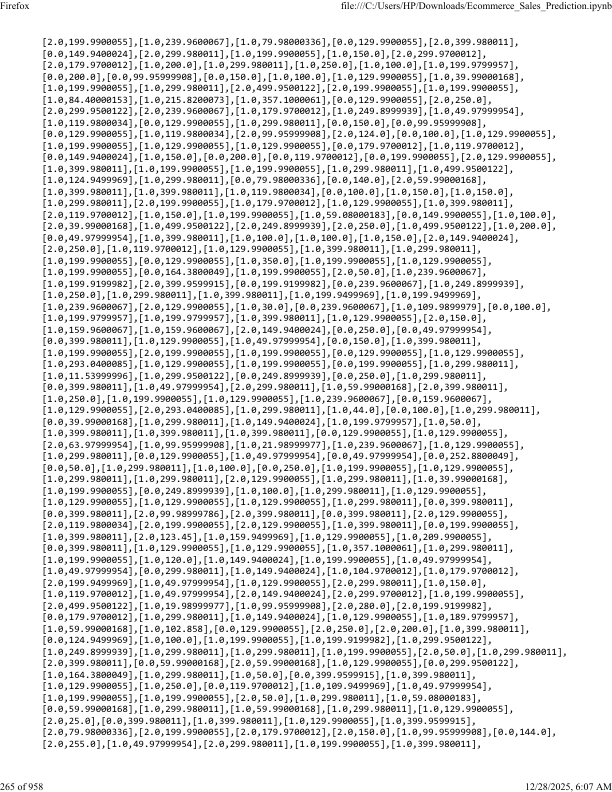


Displaying: page_604_rendered.png


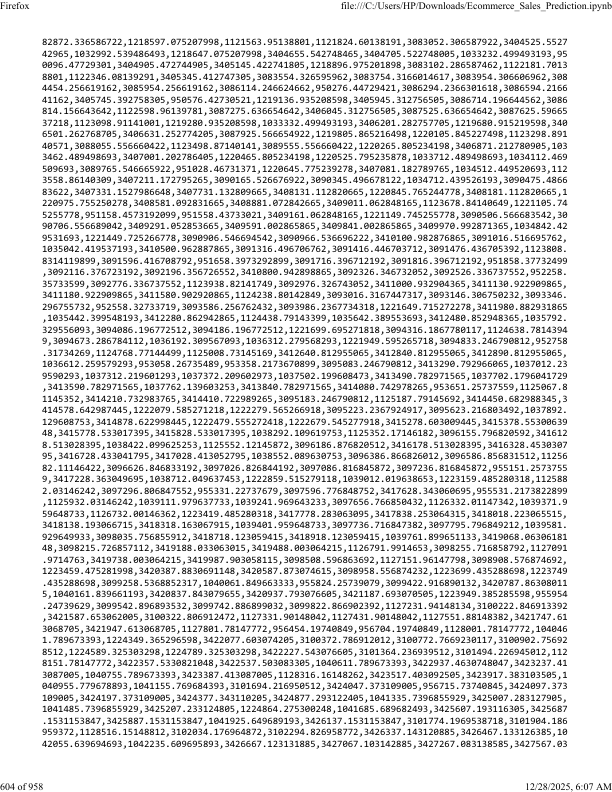


Displaying: page_155_rendered.png


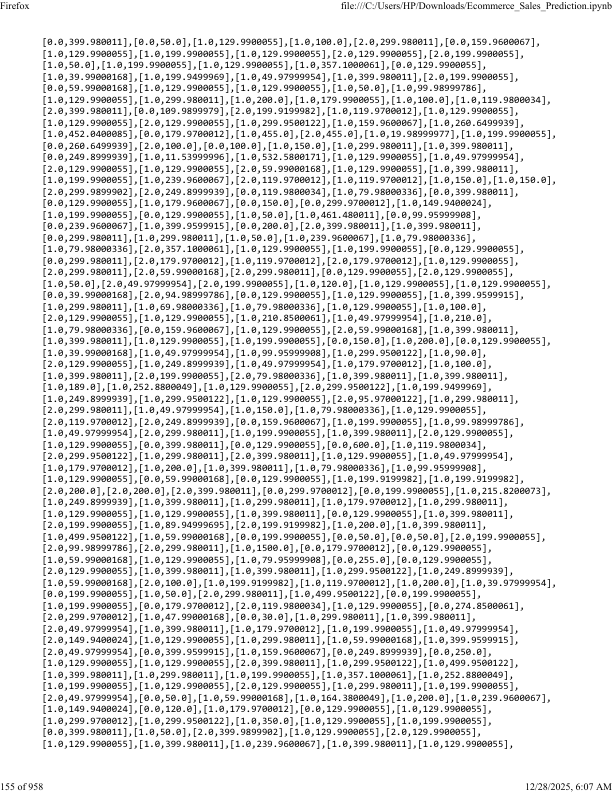


Displaying: page_785_rendered.png


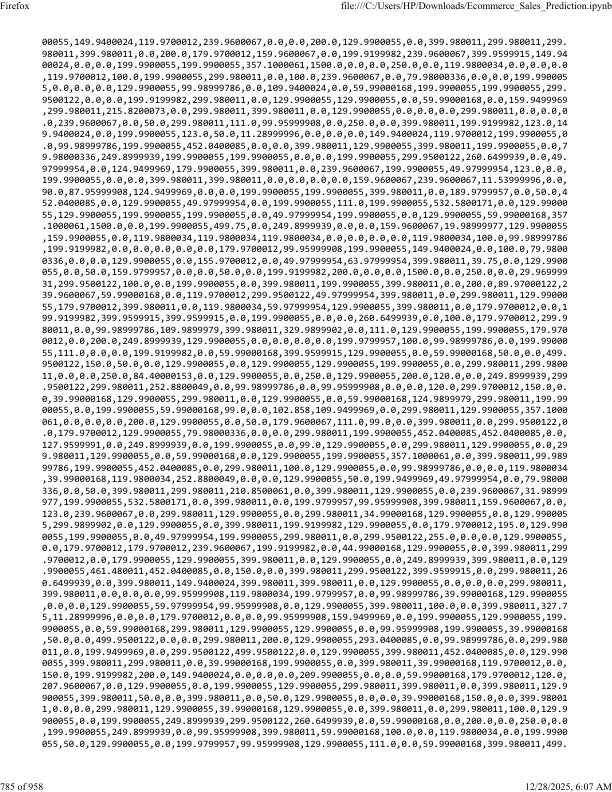


Displaying: page_656_rendered.png


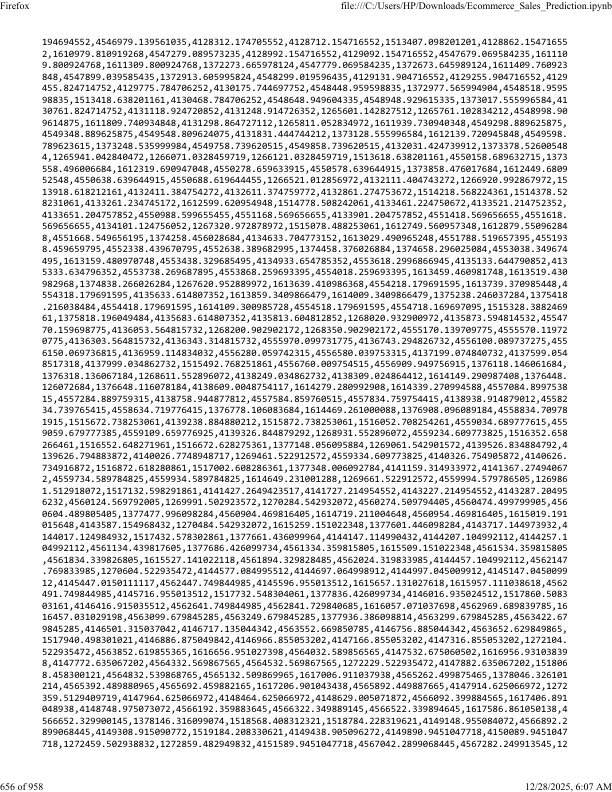

In [12]:
from IPython.display import Image, display
import os

figures_dir = "extracted_content/images"
image_files = [f for f in os.listdir(figures_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]

if len(image_files) > 0:
    print(f"Displaying up to 5 images from {figures_dir}:")
    # Display the first 5 images
    for i, image_file in enumerate(image_files[5:10]): # Modified to display the next 5 images
        print(f"\nDisplaying: {image_file}")
        display(Image(os.path.join(figures_dir, image_file)))
else:
    print(f"No image files found in {figures_dir}")

In [13]:
import os

text_file_path = "extracted_content/text/full_text.txt"

if os.path.exists(text_file_path):
    with open(text_file_path, "r", encoding="utf-8") as f:
        extracted_text = f.read()
    print("Content of extracted_text.txt:")
    print(extracted_text) # Print the full text
else:
    print(f"Text file not found at {text_file_path}")

Output hidden; open in https://colab.research.google.com to view.

In [14]:
# print(f"Total tables extracted: {len(all_results['tables'])}") # Removed the line causing NameError

if extracted_tables:
    print(f"Total tables loaded: {len(extracted_tables)}")
    print("\n--- Sample Table DataFrames/Text ---")
    # Displaying the head of the first 5 loaded DataFrames or raw text
    for i, (table_name, content) in enumerate(list(extracted_tables.items())[:5]):
        print(f"Table {i+1} ({table_name}):")
        if isinstance(content, pd.DataFrame):
            display(content.head())
        else:
            # If it's not a DataFrame (e.g., parsing failed), print the raw text content
            print(content[:500] + '...' if len(content) > 500 else content) # Print first 500 chars if long
        print("-" * 20)
else:
    print("No table data was loaded.")

Total tables loaded: 50

--- Sample Table DataFrames/Text ---
Table 1 (tables/page_67_table_34):


,"""<Figure size 1200x800 with 1 Axes>"""
0,]
1,"},"
2,"""metadata"": {},"
3,"""output_type"": ""display_data"""
4,}


--------------------
Table 2 (tables/page_45_table_26):


,"""Late Shipment Prediction Model - Accuracy: 0.6925\n"","
0,"""Late Shipment Prediction Model - Precision: 0..."
1,"""Late Shipment Prediction Model - Recall: 0.64..."
2,"""Late Shipment Prediction Model - F1-Score: 0...."
3,]
4,}


--------------------
Table 3 (tables/page_10_table_10):
        "from sklearn.preprocessing import LabelEncoder\n",
        "\n",
        "categorical_cols = [\n",
        "    \"customer_segment\",\n",
        "    \"customer_region\",\n",
        "    \"category_name\",\n",
        "    \"shipping_type\"\n",
        "]\n",
        "\n",
        "ecommerce_encoded = ecommerce.copy()\n",
        "\n",
        "encoders = {}\n",
        "for col in categorical_cols:\n",
        "    le = LabelEncoder()\n",
        "    ecommerce_encoded[col] = le.fit_...
--------------------
Table 4 (tables/page_40_table_21):


,"""",".colab-df-container {\n"","
0,"""","display:flex;\n"","
1,"""","gap: 12px;\n"","
2,"""","}\n"","
3,"""\n"",",None
4,"""",".colab-df-convert {\n"","


--------------------
Table 5 (tables/page_945_table_45):
              "      border-color: transparent;\n",
              "      border-bottom-color: var(--fill-color);\n",
              "      border-left-color: var(--fill-color);\n",
              "    }\n",
              "    20% {\n",
              "      border-color: transparent;\n",
              "      border-left-color: var(--fill-color);\n",
              "      border-top-color: var(--fill-color);\n",
              "    }\n",
              "    30% {\n",
              "      border-color: ...
--------------------


# Task
Reparse string tables from the `extracted_tables` dictionary. For each table currently stored as a string, attempt to parse it into a pandas DataFrame using multiple parsing strategies to handle varied delimiters. Finally, summarize the re-parsing results, showing how many tables were successfully converted and how many remain as strings, along with examples of each type.

## Reparse String Tables

### Subtask:
Iterate through the 'extracted_tables' dictionary. For each entry that is currently a raw string (indicating previous parsing failure), attempt to parse it into a pandas DataFrame using a more flexible method. This might involve preprocessing the string content to standardize delimiters or trying different pandas parsing functions. If successful, replace the string entry with the DataFrame in the 'extracted_tables' dictionary.


**Reasoning**:
I need to iterate through the `extracted_tables` dictionary and re-attempt parsing string entries into pandas DataFrames using different delimiters (`\s\s+`, `\t`, `,`).



In [15]:
reparsed_tables = {}

for table_name, content in extracted_tables.items():
    if isinstance(content, str):
        df = None
        try:
            # Attempt 1: two or more spaces as delimiter
            df = pd.read_csv(io.StringIO(content), sep='\s\s+', engine='python', skipinitialspace=True)
            print(f"Successfully reparsed {table_name} with '\\s\\s+'.")
        except pd.errors.ParserError:
            try:
                # Attempt 2: tab as delimiter
                df = pd.read_csv(io.StringIO(content), sep='\t')
                print(f"Successfully reparsed {table_name} with '\\t'.")
            except pd.errors.ParserError:
                try:
                    # Attempt 3: comma as delimiter
                    df = pd.read_csv(io.StringIO(content), sep=',')
                    print(f"Successfully reparsed {table_name} with ','.")
                except pd.errors.ParserError as e:
                    print(f"Failed to reparse {table_name} with any delimiter. Keeping as string. Error: {e}")
                    reparsed_tables[table_name] = content
                else:
                    reparsed_tables[table_name] = df
            else:
                reparsed_tables[table_name] = df
        else:
            reparsed_tables[table_name] = df
    else:
        # If it's already a DataFrame, keep it as is
        reparsed_tables[table_name] = content

extracted_tables = reparsed_tables

print(f"\nRe-parsing complete. Total tables (DataFrames or raw strings): {len(extracted_tables)}")
print("\n--- Sample Reparsed Table DataFrames/Text ---")
# Displaying the head of the first 5 loaded DataFrames or raw text
for i, (table_name, content) in enumerate(list(extracted_tables.items())[:5]):
    print(f"Table {i+1} ({table_name}):")
    if isinstance(content, pd.DataFrame):
        display(content.head())
    else:
        # If it's not a DataFrame, print the raw text content
        print(content[:500] + '...' if len(content) > 500 else content)
    print("-" * 20)

Successfully reparsed tables/page_10_table_10 with '\t'.
Successfully reparsed tables/page_945_table_45 with '\t'.
Successfully reparsed tables/page_947_table_47 with '\t'.
Successfully reparsed tables/page_38_table_19 with '\t'.
Successfully reparsed tables/page_11_table_11 with '\t'.
Successfully reparsed tables/page_941_table_41 with '\t'.
Successfully reparsed tables/page_48_table_29 with '\t'.
Successfully reparsed tables/page_17_table_17 with '\t'.
Successfully reparsed tables/page_13_table_13 with '\t'.
Successfully reparsed tables/page_939_table_39 with '\t'.
Successfully reparsed tables/page_15_table_15 with '\t'.
Successfully reparsed tables/page_8_table_8 with '\t'.
Successfully reparsed tables/page_47_table_28 with '\t'.
Successfully reparsed tables/page_70_table_37 with '\t'.
Successfully reparsed tables/page_49_table_30 with '\t'.
Successfully reparsed tables/page_44_table_25 with '\t'.

Re-parsing complete. Total tables (DataFrames or raw strings): 50

--- Sample Reparse

<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-1001900179.py:8: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(io.StringIO(content), sep='\s\s+', engine='python', skipinitialspace=True)


,"""<Figure size 1200x800 with 1 Axes>"""
0,]
1,"},"
2,"""metadata"": {},"
3,"""output_type"": ""display_data"""
4,}


--------------------
Table 2 (tables/page_45_table_26):


,"""Late Shipment Prediction Model - Accuracy: 0.6925\n"","
0,"""Late Shipment Prediction Model - Precision: 0..."
1,"""Late Shipment Prediction Model - Recall: 0.64..."
2,"""Late Shipment Prediction Model - F1-Score: 0...."
3,]
4,}


...

--------------------
Table 4 (tables/page_40_table_21):


,"""",".colab-df-container {\n"","
0,"""","display:flex;\n"","
1,"""","gap: 12px;\n"","
2,"""","}\n"","
3,"""\n"",",None
4,"""",".colab-df-convert {\n"","


--------------------
Table 5 (tables/page_945_table_45):


,""" border-color: transparent;\n"","
0,""" border-bottom-color: var(..."
1,""" border-left-color: var(--..."
2,""" }\n"","
3,""" 20% {\n"","
4,""" border-color: transparent..."


--------------------


**Reasoning**:
I need to count and display the number of tables that were successfully reparsed into DataFrames and those that remained as strings, along with examples of each, to summarize the re-parsing results.



In [16]:
df_count = 0
string_count = 0

# Separate DataFrames and strings for examples
df_examples = []
string_examples = []

for table_name, content in extracted_tables.items():
    if isinstance(content, pd.DataFrame):
        df_count += 1
        if len(df_examples) < 2: # Keep up to 2 DataFrame examples
            df_examples.append((table_name, content))
    else:
        string_count += 1
        if len(string_examples) < 2: # Keep up to 2 string examples
            string_examples.append((table_name, content))

print("\n--- Re-parsing Summary ---")
print(f"Total tables processed: {len(extracted_tables)}")
print(f"Successfully parsed into DataFrames: {df_count}")
print(f"Remaining as raw strings: {string_count}")

if df_examples:
    print("\n--- Example DataFrames ---")
    for name, df_content in df_examples:
        print(f"Table Name: {name}")
        display(df_content.head())
        print("\n")

if string_examples:
    print("\n--- Example Raw Strings (first 500 characters) ---")
    for name, str_content in string_examples:
        print(f"Table Name: {name}")
        print(str_content[:500] + ('...' if len(str_content) > 500 else ''))
        print("\n")


--- Re-parsing Summary ---
Total tables processed: 50
Successfully parsed into DataFrames: 50
Remaining as raw strings: 0

--- Example DataFrames ---
Table Name: tables/page_67_table_34


,"""<Figure size 1200x800 with 1 Axes>"""
0,]
1,"},"
2,"""metadata"": {},"
3,"""output_type"": ""display_data"""
4,}




Table Name: tables/page_45_table_26


,"""Late Shipment Prediction Model - Accuracy: 0.6925\n"","
0,"""Late Shipment Prediction Model - Precision: 0..."
1,"""Late Shipment Prediction Model - Recall: 0.64..."
2,"""Late Shipment Prediction Model - F1-Score: 0...."
3,]
4,}


In [17]:
import os

text_file_path = "extracted_content/text/full_text.txt"

if os.path.exists(text_file_path):
    with open(text_file_path, "r", encoding="utf-8") as f:
        extracted_text = f.read()

    # Split the text into blocks based on the page separators ("--- PAGE X ---" or "--- OCR PAGE X ---")
    # This is a heuristic and might need adjustment based on the actual file content structure
    text_blocks = extracted_text.split("--- Page")
    # Remove the first element as it's usually empty or header information before the first page
    if text_blocks and not text_blocks[0].strip():
        text_blocks = text_blocks[1:]

    print(f"Total text blocks extracted: {len(text_blocks)}")

    if text_blocks:
        print("\n--- Sample Text Blocks ---")
        # Displaying first 5 text blocks
        for i, text_block in enumerate(text_blocks[:5]):
            # Add back a simplified page indicator for context
            page_indicator = text_block.split(" ---", 1)[0].strip() if " ---" in text_block else f"Block {i+1}"
            content = text_block.split(" ---", 1)[-1].strip() if " ---" in text_block else text_block.strip()
            print(f"{page_indicator}:\n{content}\n{'-'*20}")
    else:
        print("No text blocks found.")

else:
    print(f"Text file not found at {text_file_path}")

Total text blocks extracted: 958

--- Sample Text Blocks ---
1:
{
  "cells": [
    {
      "cell_type": "markdown",
      "metadata": {
        "id": "-zTeppVCbtT8"
      },
      "source": [
        "#### A United State based Ecommerce Sales Company wants us to carry out predictions on 
Year-to-Date (YTD) Sales and generate an actionable, data-driven insights and recommendations"
      ]
    },
    {
      "cell_type": "code",
      "execution_count": null,
      "metadata": {
        "id": "cX2p7BOJbd4G"
      },
      "outputs": [],
      "source": [
        "import os\n",
        "import matplotlib\n",
        "import numpy as np\n",
        "import pandas as pd\n",
        "import matplotlib.pyplot as plt\n",
        "import seaborn as sns\n",
        "import plotly.express as px\n",
        "%matplotlib inline\n",
        "from sklearn.model_selection import train_test_split\n",
        "from sklearn.impute import SimpleImputer\n",
        "from sklearn.metrics import accuracy_sc

### **Summarize the data**
#### **Create a summary of each element extracted from the PDF. This summary will be vectorized and used in the retrieval process**

### **Summarize the data**
#### **Create a summary of each element extracted from the PDF. This summary will be vectorized and used in the retrieval process**

In [18]:
%pip install -Uq langchain-groq

In [19]:
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

### **Text and Table summaries**
#### **To summarize the Texts and Tables, i will use groq_chat_model = ChatGroq(model_name="llama3-8b-8192"**

In [ ]:
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from IPython.display import Markdown # Import Markdown
import os # Import os to access environment variables

# Initialize the ChatGroq model for text and table summaries
# You can choose a suitable model from the available Groq models
# Retrieve API key from environment variable, which should be set from Colab secrets
groq_api_key = os.environ.get("GROQ_API_KEY")
if not groq_api_key:
    raise ValueError("GROQ_API_KEY not found in environment variables. Please ensure DVgd59laVwT3 has been executed and the key is in Colab secrets.")

groq_chat_model = ChatGroq(model_name="llama-3.1-8b-instant", temperature=0, groq_api_key=groq_api_key) # Using a smaller, faster model for summarization and passing the API key

# Define a prompt template for summarization
summary_prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a helpful assistant that summarizes text and table content concisely."),
    ("user", "Please provide a concise summary of the following content:\n\n{content}")
])

# Chain the model and parser
summary_chain = summary_prompt | groq_chat_model | StrOutputParser()

# Split extracted_text into chunks for summarization
# This assumes extracted_text has been loaded from the text file in a previous step
if 'extracted_text' in locals() and extracted_text:
    # Using the same splitting logic as in cell mbRek984rLVX
    text_blocks = extracted_text.split("--- Page")
    if text_blocks and not text_blocks[0].strip():
        text_blocks = text_blocks[1:]

    text_chunks = []
    for i, text_block in enumerate(text_blocks):
        # Reconstruct the page content without the indicator for summarization
        content = text_block.split(" ---", 1)[-1].strip() if " ---" in text_block else text_block.strip()
        if content:
            text_chunks.append(content)
    print(f"Created {len(text_chunks)} text chunks for summarization.")
else:
    text_chunks = []
    print("extracted_text variable is not defined or is empty. No text chunks created.")


# Generate summaries for text chunks
text_chunk_summaries = {}
print("Generating summaries for text chunks...")
if text_chunks:
    for i, chunk in enumerate(text_chunks):
        try:
            summary = summary_chain.invoke({"content": chunk})
            text_chunk_summaries[f"text_chunk_{i+1}"] = summary
            # print(f"Generated summary for text chunk {i+1}")
        except Exception as e:
            print(f"Error summarizing text chunk {i+1}: {e}")
            text_chunk_summaries[f"text_chunk_{i+1}"] = None
else:
    print("text_chunks variable is empty. No text summaries generated.")


# Generate summaries for tables
table_summaries = {}
print("\nGenerating summaries for tables...")
# Ensure extracted_tables is defined and not empty before iterating
if 'extracted_tables' in locals() and extracted_tables:
    for table_name, df in extracted_tables.items():
        try:
            # Convert DataFrame to a readable string format for summarization
            table_content = df.to_string()
            summary = summary_chain.invoke({"content": table_content})
            table_summaries[table_name] = summary
            # print(f"Generated summary for table {table_name}")
        except Exception as e:
            print(f"Error summarizing table {table_name}: {e}")
            table_summaries[table_name] = None
else:
    print("extracted_tables variable is not defined or is empty. No table summaries generated.")


# Display a few sample text chunk summaries
if text_chunk_summaries:
    print("\n--- Sample Text Chunk Summaries ---")
    for i, (chunk_name, summary) in enumerate(list(text_chunk_summaries.items())[:5]):
        print(f"Summary for {chunk_name}:")
        display(Markdown(summary))
        print("-" * 20)

# Display a few sample table summaries
if table_summaries:
    print("\n--- Sample Table Summaries ---")
    for i, (table_name, summary) in enumerate(list(table_summaries.items())[:5]):
        print(f"Summary for {table_name}:")
        display(Markdown(summary))
        print("-" * 20)


Created 958 text chunks for summarization.
Generating summaries for text chunks...


In [ ]:
%pip install -Uq langchain_openai

In [ ]:
# ==========================================================
# ✅ FIXED IMAGE SUMMARIZATION WITH GPT-4o (OpenAI API)
# ==========================================================

import base64, os, io, json
from PIL import Image
from tqdm import tqdm
import pandas as pd
from openai import OpenAI

# -----------------------------------------------------------
# 1️⃣ Initialize OpenAI client
# -----------------------------------------------------------
# Retrieve API key from environment variables (set by DVgd59laVwT3 after loading from Colab secrets)
deepseek_api_key = os.environ.get("DEEPSEEK_API_KEY")
if not deepseek_api_key:
    raise ValueError("DEEPSEEK_API_KEY not found in environment variables. Please ensure DVgd59laVwT3 has been executed and the key is in Colab secrets.")

client = deepseek(api_key=deepseek_api_key)

# -----------------------------------------------------------
# 2️⃣ Helper: encode image to base64
# -----------------------------------------------------------
def encode_image_to_base64(image_path):
    with open(image_path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")

# -----------------------------------------------------------
# 3️⃣ Helper: summarize an image
# -----------------------------------------------------------
def summarize_image_openai(image_path):
    try:
        image_base64 = encode_image_to_base64(image_path)
        prompt_text = (
            "Describe this image in detail, focusing on any charts, graphs, or tables. "
            "If it's a chart, mention the axes, trends, and key data insights. "
            "If it's a table, describe the structure and what it represents."
        )

        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {
                    "role": "user",
                    "content": [
                        {"type": "text", "text": prompt_text},
                        {
                            "type": "image_url",
                            "image_url": {
                                "url": f"data:image/png;base64,{image_base64}"
                            },
                        },
                    ],
                }
            ],
        )

        summary = response.choices[0].message.content
        return summary.strip() if summary else "No summary returned."

    except Exception as e:
        return f"❌ Error summarizing {os.path.basename(image_path)}: {e}"

# -----------------------------------------------------------
# 4️⃣ Process all images in your folder
# -----------------------------------------------------------
figures_dir = "extracted_content/images" # Corrected path
image_files = [
    os.path.join(figures_dir, f)
    for f in os.listdir(figures_dir)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
]

print(f"✅ OpenAI API key successfully loaded.")
print(f"📁 Found {len(image_files)} image(s) in {figures_dir}.")
print("🔍 Generating summaries for all images...")

image_summaries = {}

for img_path in tqdm(image_files):
    summary = summarize_image_openai(img_path)
    image_summaries[os.path.basename(img_path)] = summary

print("✅ Summarization complete.")

# -----------------------------------------------------------
# 5️⃣ Save results
# -----------------------------------------------------------
out_df = pd.DataFrame(image_summaries.items(), columns=["image_name", "summary"])
out_df.to_csv("openai_image_summaries.csv", index=False)

print("\n💾 All summaries saved to openai_image_summaries.csv")
print("\n--- 🧠 Sample Image Summaries ---")

for i, (img, summary) in enumerate(list(image_summaries.items())[:5]):
    print(f"\n🖼️ {img}\n{summary}\n" + "-"*50)